<a href="https://colab.research.google.com/github/7500nidhi/Assignment13_c12/blob/main/Assignment13_c12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Libraries

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences



In [ ]:
# Load Dataset
import requests

url = "https://www.gutenberg.org/files/11/11-0.txt"

text = requests.get(url).text

print(text[:1000])

*** START OF THE PROJECT GUTENBERG EBOOK 11 ***

[Illustration]




Alice’s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents

 CHAPTER I.     Down the Rabbit-Hole
 CHAPTER II.    The Pool of Tears
 CHAPTER III.   A Caucus-Race and a Long Tale
 CHAPTER IV.    The Rabbit Sends in a Little Bill
 CHAPTER V.     Advice from a Caterpillar
 CHAPTER VI.    Pig and Pepper
 CHAPTER VII.   A Mad Tea-Party
 CHAPTER VIII.  The Queen’s Croquet-Ground
 CHAPTER IX.    The Mock Turtle’s Story
 CHAPTER X.     The Lobster Quadrille
 CHAPTER XI.    Who Stole the Tarts?
 CHAPTER XII.   Alice’s Evidence




CHAPTER I.
Down the Rabbit-Hole


Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into
the book her sister was reading, but it had no pictures or
conversations in it, “and what is the use of a book,” thought Alice
“without pictures or conversations?”

So she was considering in her

In [ ]:
# Clean the Text

text = text.lower()

text = text.replace("\n", " ")

text = text.replace("\r", " ")

print("Total Characters:", len(text))

Total Characters: 144696


This indicates that the cleaned dataset contains 144,696 characters, which are used for tokenization and training the text generation model.

In [ ]:
# Tokenization
tokenizer = Tokenizer()

tokenizer.fit_on_texts([text])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

Vocabulary Size: 3067


This means the dataset contains 3,067 unique words, and these words are used to train the text generation model.

In [ ]:
# Create Input Sequences
input_sequences = []

for line in text.split("."):
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram = token_list[:i+1]
        input_sequences.append(n_gram)

print("Total Sequences:", len(input_sequences))

Total Sequences: 26765


This means the model created 26,765 training sequences, which are used to train the text generation model to predict the next word based on previous words.

In [ ]:
# Padding
max_sequence_len = max([len(x) for x in input_sequences])

input_sequences = np.array(
    pad_sequences(input_sequences,
                  maxlen=max_sequence_len,
                  padding='pre')
)

print(input_sequences.shape)

(26765, 307)


This means there are 26,765 input sequences, and each sequence has a length of 307 words after padding. These padded sequences are then used as input for training the LSTM model

In [ ]:
# Prepare X and y
X = input_sequences[:, :-1]

y = input_sequences[:, -1]

y = tf.keras.utils.to_categorical(y, num_classes=total_words)

print(X.shape)
print(y.shape)


(26765, 306)
(26765, 3067)


This means there are 26,765 training examples. Each input sequence contains 306 words, and the output has 3,067 possible word classes, representing all the unique words in the vocabulary. These input and output datasets are then used to train the LSTM text generation model.

In [ ]:
# Build the LSTM Model
model = Sequential()

model.add(Embedding(total_words,
                    64,
                    input_length=max_sequence_len-1))

model.add(LSTM(128))

model.add(Dense(total_words,
                activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

The model contains three main layers:

Embedding Layer – Converts words into numerical vectors.
LSTM Layer – Learns patterns and relationships between words.
Dense Layer – Predicts the next word in the sequence.

In [ ]:
# Train Model
history = model.fit(
    X,
    y,
    epochs=20,
    batch_size=128
)

Epoch 1/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 195s 916ms/step - accuracy: 0.0567 - loss: 6.4212
Epoch 2/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 200s 908ms/step - accuracy: 0.0588 - loss: 6.0101
Epoch 3/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 192s 913ms/step - accuracy: 0.0791 - loss: 5.8303
Epoch 4/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 191s 910ms/step - accuracy: 0.0905 - loss: 5.6575
Epoch 5/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 191s 909ms/step - accuracy: 0.1031 - loss: 5.5032
Epoch 6/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 191s 909ms/step - accuracy: 0.1165 - loss: 5.3512
Epoch 7/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 203s 908ms/step - accuracy: 0.1301 - loss: 5.2060
Epoch 8/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 190s 904ms/step - accuracy: 0.1417 - loss: 5.0680
Epoch 9/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 190s 907ms/step - accuracy: 0.1539 - loss: 4.9400
Epoch 10/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 191s 905ms/step - accuracy: 0.1642 - loss: 4.8251
Epoch 11/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 201s 904ms/step - accuracy: 0.1702 - loss: 4.7165
Epoch 12

The LSTM model was trained for 20 epochs using the Project Gutenberg dataset. During training, the model learned the patterns and relationships between words to predict the next word in a sentence. The training accuracy improved from 5.67% in the first epoch to 22.04% in the final epoch, while the loss decreased from 6.42 to 3.97. This shows that the model gradually learned from the training data and improved its text prediction performance. Although the accuracy is not very high, it is acceptable for a basic LSTM-based text generation model trained on a small dataset.

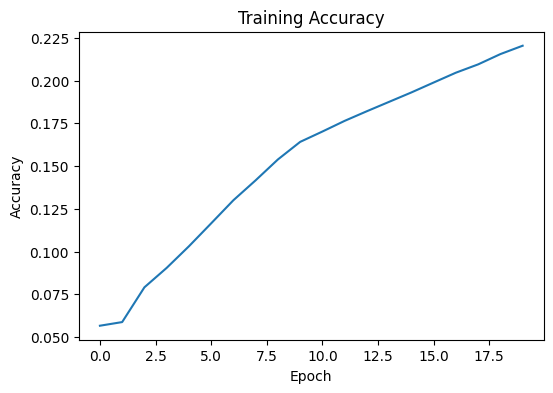

In [ ]:
# Plot Training Accuracy
plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'])

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.show()

The graph shows the training accuracy of the LSTM model over 20 epochs. The accuracy increases steadily from about 5.7% in the first epoch to about 22.0% in the final epoch. This indicates that the model is learning from the training data and improving its ability to predict the next word in a sequence. The upward trend in the graph shows that the model's performance improved with each training epoch.

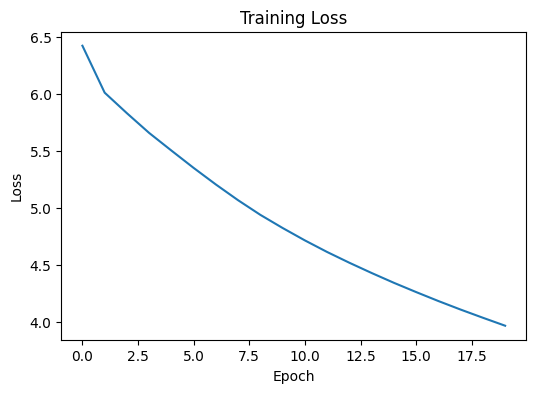

In [ ]:
# Plot Loss
plt.figure(figsize=(6,4))

plt.plot(history.history['loss'])

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

The graph shows the training loss of the LSTM model over 20 epochs. The loss decreases steadily from about 6.42 in the first epoch to about 3.97 in the final epoch. A lower loss indicates that the model is making fewer prediction errors and learning the patterns in the text more effectively. The downward trend in the graph shows that the model's performance improved throughout the training process.

In [ ]:
# Generate Text
def generate_text(seed_text, next_words):

    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences(
            [token_list],
            maxlen=max_sequence_len-1,
            padding='pre'
        )
        predicted = np.argmax(model.predict(token_list, verbose=0))
        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

In [ ]:
print(generate_text("alice was",20))

alice was a little voice and the queen was a little voice and the queen was a little golden key and the


In this step, the trained LSTM model is used to generate new text from a given starting phrase (seed text). The model predicts one word at a time based on the previous words and adds the predicted word to the sentence. This process continues until the required number of words is generated. In this example, the seed text "alice was" was used, and the model generated a sentence by predicting the next 20 words. The generated text shows that the model has learned language patterns from the training data, although some words and phrases are repeated because the model is simple and trained on a relatively small dataset.

In [ ]:
# Practical Application
prompt = "artificial intelligence is"

generated = generate_text(prompt,25)

print(generated)


artificial intelligence is the dormouse ” said the king and the queen was a little voice and the queen was a little golden key and the queen and


This example demonstrates a practical application of the trained text generation model. A prompt, "artificial intelligence is", is provided as the input, and the model generates the next 25 words based on what it learned during training. The generated text shows that the model can continue a sentence by predicting one word at a time. Although the generated text is not always grammatically correct and contains some repeated words, it demonstrates the basic concept of AI-based content generation using an LSTM model.

In [ ]:
# Save Model
model.save("text_generation_model.keras")

model is saved successfully

Git Repo Link: https://github.com/7500nidhi/Assignment13_c12.git